# Jem — Five statistical breach-prediction methods

**Standalone, executed notebook.** Open in Colab and run top to bottom. Upload the
seven original CSVs when prompted. Uses pandas, NumPy, SciPy and Matplotlib;
no GPU, API key, classifier or regression training is required.

Stage 1 is included for data checks and clean weekly labels. Its original
shift-date Wednesday snapshots are NOT the main evaluation inputs below: the
comparison rebuilds a strict end-of-Wednesday snapshot and handles unavailable
clock-outs using earlier duration estimates. The old convention is a sensitivity.

Five candidates: Bayesian weekly days, matched remainder, smoothed risk table,
empirical forecast errors, and correlated-hours probability. The naive formula
and a pooled history point projection are included. Every alert policy uses earlier
historical predictions only. No current-week predictions.csv is produced.

All supplied historical weeks have already informed method design. This is
exploratory chronological replay, not independent or untouched validation.

If Stage 1 is already loaded in another notebook, copy only the section starting
**Five statistical methods — chronological comparison** and its following cells.


## Results on this supplied export

Sequential evaluation over the final six completed weeks. Each candidate's F2 threshold is selected from earlier out-of-time predictions. Naive and pooled history point projections use >55-hour rules.

| Method | Breaches caught | False alerts | Missed | Total review alerts | F2 |
|---|---:|---:|---:|---:|---:|
| bayesian_days | 22/44 | 141 | 22 | 220 | 0.324 |
| correlated_hours | 24/44 | 137 | 20 | 200 | 0.356 |
| empirical_errors | 19/44 | 163 | 25 | 230 | 0.265 |
| history_point | 0/44 | 0 | 44 | 1 | 0.000 |
| matched_remainder | 23/44 | 177 | 21 | 254 | 0.306 |
| naive | 23/44 | 260 | 21 | 347 | 0.251 |
| smoothed_table | 31/44 | 283 | 13 | 381 | 0.316 |

Total review alerts include uncertain-outcome cases, which are excluded from the confusion matrix. The later sections contain probability quality, fixed review budgets, weekly results, a high-recall policy, cutoff sensitivity, errors and verification checks.

These results cannot be compared directly to the earlier 6/11 logistic result: the primary cutoff and evaluation period differ. No logistic regression is retrained here. A method that wins this reused dataset has not established independent generalisation.


## How to interpret this first comparison

The question is a tail probability: **P(remaining hours > 55 − Wednesday hours)**.
A historical mean alone answers a different question and can miss occasional
extra days. The five methods estimate this tail in different ways.

- **Correlated hours** has the highest primary F2 (0.356), average precision
  (0.209), and lowest Brier score (0.0349) among these fixed candidates. It catches
  24/44 breaches with 137 false alerts, versus the naive rule's 23/44 and 260.
  At 20 reviews per week it catches 19/44, versus 10/44 for the naive ranking.
  Its normal-distribution and covariance-pooling assumptions still require scrutiny.
- **Smoothed table** catches the most breaches under the primary policy (31/44),
  but produces 283 false alerts. This is a different recall/workload trade-off,
  not an unqualified improvement.
- **Bayesian days** catches 22/44 with 141 false alerts. Exchangeable days and
  independent durations within day-count scenarios are substantial assumptions.
- **Matched remainder** catches 23/44 with 177 false alerts. It preserves whole
  remaining-week scenarios, but sparse personal history requires substantial pooling.
- **Empirical errors** catches 19/44 with 163 false alerts. Its probability quality
  does not beat the earlier-prevalence reference on Brier score in this replay.

The central history projection catches none at a >55-hour decision rule. That
supports the concern about using a typical week to detect exceptional weeks;
this pooled projection is not an exact reproduction of the old Stage 2 rule.

The secondary policy seeks at least 80% recall on earlier predictions. It does
not guarantee that recall subsequently: the smoothed table catches 43/44 but
raises 886 false alerts, while correlated hours catches 34/44 with 316 false
alerts. The missed-breach problem remains material. Select a policy using an
explicit review capacity or missed-breach/false-alert trade-off, rather than
silently treating F2 as the business objective.

All counts above concern clean, scorable employee-weeks. Total workload also
includes alerts whose final outcomes are uncertain. Primary method settings were
fixed for this run; selecting a winner after inspecting these same weeks is still
exploratory. New completed weeks are needed for independent confirmation.


# Jem assessment — Stage 1: analytical dataset

Run cells in order. Upload the seven original CSVs when prompted in Colab.
This stage produces auditable historical Wednesday snapshots and a snapshot for
every registered employee in the latest reporting week. It does not fit a model,
impute durations, classify notes, or generate breach predictions.

**Hours convention.** A shift belongs wholly to its `shift_date`, including an
overnight end the following morning. This reproduces the supplied weekly export.
Times are assumed to be local South African wall-clock times; elapsed duration is
treated as worked hours because break information is absent. Shifts are assumed
shorter than 24 hours. Equal start/end times are ambiguous and flagged, not
interpreted as a 24-hour shift.

**Availability assumption.** A reporting day includes completed overnight records
associated with that date. This is a shift-date snapshot, NOT a literal midnight
snapshot. Twelve current Wednesday records finish on Thursday in the supplied
export. There are no record-creation/revision timestamps, so point-in-time
availability cannot be proven. Historical replay assumes the records existed in
their supplied form by the reporting cut-off under this convention.

**Scope.** Use the assessment rule `weekly_hours > 55`. Payment premiums do not
multiply hours. Client-requested hours still count. Retain the latest represented
week for current scoring; never use it as historical ground truth in this stage.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:  # Also allows these functions to run in a normal Python script.
    display = print

pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 70)

BREACH_HOURS = 55.0
HISTORICAL_CUTOFF_DAY = 2  # Monday=0; Wednesday=2. Change to 1 or 3 later.
DATA_DIR = Path("/content") if Path("/content").exists() else Path("project_sources")
FILENAMES = ["employees.csv", "sites.csv", "shifts.csv", "shift_notes.csv",
             "public_holidays.csv", "weekly_summary.csv", "payroll_details.csv"]

def locate_file(name):
    # Accept original names and the numbered copies supplied for this analysis.
    matches = list(DATA_DIR.glob(name)) + list(DATA_DIR.glob(f"*-{name}"))
    assert len(matches) <= 1, f"Multiple copies of {name}; select one export."
    return matches[0] if matches else None

missing_files = [name for name in FILENAMES if locate_file(name) is None]
if missing_files:
    try:
        from google.colab import files
    except ImportError:
        raise FileNotFoundError(f"Place {missing_files} in {DATA_DIR.resolve()}")
    print("Upload the missing CSV files:", missing_files)
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    for name, content in files.upload().items():
        (DATA_DIR / Path(name).name).write_bytes(content)

assert all(locate_file(name) is not None for name in FILENAMES), "Missing input files."
# Read strings first: preserve IDs, leading zeros and literal note text such as n/a.
raw = {name[:-4]: pd.read_csv(locate_file(name), dtype="string", keep_default_na=False)
       for name in FILENAMES}
employees = raw["employees"].copy()
sites = raw["sites"].copy()
notes = raw["shift_notes"].copy()
holidays = raw["public_holidays"].copy()
summary = raw["weekly_summary"].copy()
payroll = raw["payroll_details"].copy()


## Input inspection and integrity

The inspection lists every file's shape and fields without displaying payroll
banking or tax data. Payroll is loaded and its employee keys checked; it contributes
no features. Note text is preserved unchanged. Blank notes are different from the
literal placeholder `n/a`.

The register has no employment start/end dates. We assume the supplied register
describes the workforce throughout the export. A historical employee-week with no
shift records is uncertain, not a confirmed zero-hour week.


In [2]:
inventory = pd.DataFrame([
    {"file": name + ".csv", "rows": len(df), "columns": len(df.columns),
     "duplicate_rows": int(df.duplicated().sum()),
     "blank_cells": int(df.apply(lambda col: col.str.strip().eq("").sum()).sum()),
     "fields": ", ".join(df.columns)}
    for name, df in raw.items()
])
display(inventory)

def assert_key(df, columns):
    assert not df[columns].apply(lambda c: c.str.strip().eq("")).any().any()
    assert not df.duplicated(columns).any(), f"Duplicate key: {columns}"

for df, key in [(employees, ["employee_id"]), (sites, ["site_id"]),
                (raw["shifts"], ["shift_id"]), (notes, ["shift_id"]),
                (payroll, ["employee_id"]), (holidays, ["date"]),
                (summary, ["employee_id", "week_starting"])]:
    assert_key(df, key)

employee_ids = set(employees.employee_id)
site_ids = set(sites.site_id)
assert set(raw["shifts"].employee_id) <= employee_ids
assert set(raw["shifts"].site_id) <= site_ids
assert set(employees.primary_site_id) <= site_ids
assert set(notes.shift_id) <= set(raw["shifts"].shift_id)
assert set(summary.employee_id) <= employee_ids
assert set(payroll.employee_id) == employee_ids

employees["contract_ordinary_hours"] = pd.to_numeric(employees.contract_ordinary_hours)
assert employees.contract_ordinary_hours.eq(45).all(), "Review the fixed 55-hour rule."
holidays["date"] = pd.to_datetime(holidays.date, format="%Y-%m-%d", errors="raise")
summary["week_starting"] = pd.to_datetime(summary.week_starting, format="%Y-%m-%d")
assert summary.week_starting.dt.dayofweek.eq(0).all()
for col in ["total_hours", "overtime_hours", "breached"]:
    summary[col] = pd.to_numeric(summary[col], errors="raise")
assert np.isfinite(summary[["total_hours", "overtime_hours", "breached"]]).all().all()
assert summary.total_hours.ge(0).all()
assert summary.breached.isin([0, 1]).all()
print("Empty notes:", notes.note.str.strip().eq("").sum())
print("Literal n/a notes:", notes.note.str.strip().str.lower().eq("n/a").sum())
display(employees.groupby(["role", "shift_pattern"]).size().rename("employees").reset_index())


Empty notes: 22
Literal n/a notes: 29


,file,rows,columns,duplicate_rows,blank_cells,fields
0,employees.csv,213,8,0,0,"employee_id, full_name, id_number, role, primary_site_id, shift_pattern, contract_ordinary_hours, employment_type"
1,sites.csv,6,3,0,0,"site_id, site_name, province"
2,shifts.csv,8863,6,0,184,"shift_id, employee_id, site_id, shift_date, clock_in_time, clock_out_time"
3,shift_notes.csv,2117,3,0,22,"shift_id, logged_by, note"
4,public_holidays.csv,2,2,0,0,"date, name"
5,weekly_summary.csv,2122,5,0,0,"employee_id, week_starting, total_hours, overtime_hours, breached"
6,payroll_details.csv,213,10,0,0,"employee_id, full_name, id_number, bank_name, branch_code, account_number, account_type, tax_number, hourly_rate, pay_frequency"


,role,shift_pattern,employees
0,Cleaner,day,37
1,Driver,day,26
2,Kitchen Assistant,day,43
3,Security Guard,day,40
4,Security Guard,night,30
5,Supervisor,day,37


## Parse times and infer the reporting period

Missing clock-outs remain missing. A malformed nonblank time or zero duration is
flagged as invalid. Recorded hours sum only valid completed durations; a total of
zero with missing records does not mean no hours were worked.

The latest `shift_date` supplies the default reporting date, not today's system
date and not the latest clock-out timestamp. We assume that date is fully covered
under the shift-date convention. The export has no completeness metadata; a
future application should display this date for confirmation.


In [3]:
shifts = raw["shifts"].copy()
shifts["shift_date"] = pd.to_datetime(shifts.shift_date, format="%Y-%m-%d", errors="raise")
assert shifts.shift_date.notna().all() and len(shifts) > 0
shifts["week_start"] = shifts.shift_date - pd.to_timedelta(shifts.shift_date.dt.dayofweek, unit="D")

def parse_clock(series):
    text = series.str.strip()
    valid = text.str.fullmatch(r"(?:[01]\d|2[0-3]):[0-5]\d", na=False)
    return pd.to_timedelta(text.where(valid) + ":00", errors="coerce")

clock_in = parse_clock(shifts.clock_in_time)
clock_out = parse_clock(shifts.clock_out_time)
shifts["missing_clockout"] = shifts.clock_out_time.str.strip().eq("")
shifts["start_at"] = shifts.shift_date + clock_in
shifts["end_at"] = shifts.shift_date + clock_out
shifts["overnight"] = (clock_out < clock_in).fillna(False)
shifts.loc[shifts.overnight, "end_at"] += pd.Timedelta(days=1)
duration = (shifts.end_at - shifts.start_at).dt.total_seconds() / 3600
shifts["invalid_time"] = (
    clock_in.isna() | (~shifts.missing_clockout & clock_out.isna())
    | duration.le(0) | duration.ge(24)
)
shifts["recorded_hours"] = duration.mask(shifts.invalid_time)
assert shifts.recorded_hours.dropna().gt(0).all()
assert shifts.recorded_hours.dropna().lt(24).all()
assert shifts.loc[shifts.missing_clockout, "recorded_hours"].isna().all()

REPORTING_DATE = shifts.shift_date.max()
CURRENT_WEEK = REPORTING_DATE - pd.Timedelta(days=REPORTING_DATE.dayofweek)
weeks = pd.date_range(shifts.week_start.min(), CURRENT_WEEK, freq="7D")
coverage = (shifts.groupby("week_start").agg(
    rows=("shift_id", "size"), employees=("employee_id", "nunique"),
    dates_present=("shift_date", "nunique"),
    missing_clockouts=("missing_clockout", "sum"), invalid_times=("invalid_time", "sum"),
    overnight_shifts=("overnight", "sum"),
).reindex(weeks, fill_value=0).rename_axis("week_start").reset_index())
coverage["week_end"] = coverage.week_start + pd.Timedelta(days=6)
# Conservative coverage proxy, not proof that every site's export is complete.
coverage["calendar_coverage_ok"] = coverage.dates_present.eq(7) & coverage.week_end.le(REPORTING_DATE)
print("Shift-date range:", shifts.shift_date.min().date(), "to", REPORTING_DATE.date())
print("Current week:", CURRENT_WEEK.date(), "| reporting day:", REPORTING_DATE.day_name())
print("Latest supplied clock-out:", shifts.end_at.max())
display(coverage)
display(shifts.recorded_hours.describe().to_frame())


Shift-date range: 2026-06-08 to 2026-08-12
Current week: 2026-08-10 | reporting day: Wednesday
Latest supplied clock-out: 2026-08-13 08:15:00


,week_start,rows,employees,dates_present,missing_clockouts,invalid_times,overnight_shifts,week_end,calendar_coverage_ok
0,2026-06-08,921,213,7,15,0,103,2026-06-14,True
1,2026-06-15,963,213,7,13,0,114,2026-06-21,True
2,2026-06-22,944,213,7,25,0,107,2026-06-28,True
3,2026-06-29,915,213,7,19,0,106,2026-07-05,True
4,2026-07-06,941,213,7,26,0,106,2026-07-12,True
5,2026-07-13,938,213,7,19,0,108,2026-07-19,True
6,2026-07-20,942,213,7,24,0,110,2026-07-26,True
7,2026-07-27,929,213,7,15,0,107,2026-08-02,True
8,2026-08-03,940,213,7,25,0,105,2026-08-09,True
9,2026-08-10,430,207,3,3,0,44,2026-08-16,False


,recorded_hours
count,8679.000000
mean,9.775579
std,2.047751
min,3.500000
25%,8.750000
50%,9.500000
75%,11.250000
max,13.500000


## Detect overlaps without removing records

Two valid intervals overlap when their intersection has positive duration.
Touching endpoints do not overlap. Detection works across sites, midnight and
week boundaries, and records every pair even when several intervals overlap.
Missing/invalid ends cannot be checked reliably; those remain separate flags.

`all_overlap_pairs` is an audit of the entire export only. Snapshot features below
recompute overlaps from the data visible at their own cut-off. Do not merge the
full-export flags into historical features.


In [4]:
def find_overlaps(frame):
    columns = ["employee_id", "shift_id_left", "shift_id_right", "overlap_hours"]
    pairs = []
    valid = frame.loc[frame.recorded_hours.notna()].sort_values(["employee_id", "start_at", "shift_id"])
    for employee_id, group in valid.groupby("employee_id", sort=False):
        active = []
        for row in group.itertuples(index=False):
            active = [previous for previous in active if previous.end_at > row.start_at]
            for previous in active:
                hours = (min(previous.end_at, row.end_at) - row.start_at).total_seconds() / 3600
                pairs.append((employee_id, previous.shift_id, row.shift_id, hours))
            active.append(row)
    return pd.DataFrame(pairs, columns=columns)

all_overlap_pairs = find_overlaps(shifts)
overlap_ids = set(all_overlap_pairs.shift_id_left) | set(all_overlap_pairs.shift_id_right)
print("Overlap pairs:", len(all_overlap_pairs), "| affected shifts:", len(overlap_ids))
display(all_overlap_pairs.head(10))
quality_records = shifts.loc[
    shifts.missing_clockout | shifts.invalid_time | shifts.shift_id.isin(overlap_ids),
    ["shift_id", "employee_id", "site_id", "shift_date", "start_at", "end_at",
     "recorded_hours", "missing_clockout", "invalid_time"]
].copy()
quality_records["overlap_in_full_export"] = quality_records.shift_id.isin(overlap_ids)
display(quality_records.head(10))


Overlap pairs: 126 | affected shifts: 252


,employee_id,shift_id_left,shift_id_right,overlap_hours
0,E1005,S100208,S100210,4.00
1,E1006,S100248,S100252,4.00
2,E1006,S100253,S100256,4.00
3,E1007,S100295,S100298,4.00
4,E1015,S100630,S100634,4.00
5,E1015,S100635,S100632,3.75
6,E1016,S100668,S100671,4.00
7,E1019,S100818,S100820,4.00
8,E1020,S100850,S100853,4.00
9,E1020,S100851,S100854,4.00


,shift_id,employee_id,site_id,shift_date,start_at,end_at,recorded_hours,missing_clockout,invalid_time,overlap_in_full_export
96,S107040,E1161,ST-05,2026-06-08,2026-06-08 08:00:00,2026-06-08 20:00:00,12.00,False,False,True
97,S107043,E1161,ST-01,2026-06-08,2026-06-08 08:00:00,2026-06-08 12:00:00,4.00,False,False,True
138,S100245,E1006,ST-04,2026-06-09,2026-06-09 07:15:00,NaT,NaN,True,False,False
154,S101273,E1030,ST-03,2026-06-09,2026-06-09 07:00:00,NaT,NaN,True,False,False
176,S102834,E1065,ST-03,2026-06-09,2026-06-09 19:30:00,NaT,NaN,True,False,False
194,S104092,E1094,ST-04,2026-06-09,2026-06-09 19:00:00,2026-06-10 05:45:00,10.75,False,False,True
195,S104094,E1094,ST-03,2026-06-09,2026-06-09 18:00:00,2026-06-09 22:00:00,4.00,False,False,True
201,S104623,E1106,ST-03,2026-06-09,2026-06-09 08:00:00,2026-06-09 20:15:00,12.25,False,False,True
202,S104627,E1106,ST-01,2026-06-09,2026-06-09 06:00:00,2026-06-09 10:00:00,4.00,False,False,True
237,S107084,E1162,ST-03,2026-06-09,2026-06-09 09:00:00,NaT,NaN,True,False,False


## Build a snapshot from visible records only

This function uses no weekly summary, outcome table, full-export overlap flags,
payroll fields or note classifications. Static register attributes are assumed
valid throughout the period. The holiday calendar is assumed known in advance.

No imputation is performed: `imputed_hours_so_far` is explicitly zero. Missing
shift durations remain unknown. The mean duration is missing if no completed
shift exists. Every registered employee is retained, including those with no
records. A prior Sunday's interval can flag an overlap with a Monday shift, but
its hours are never added to the new week.


In [5]:
REGISTER_COLUMNS = ["employee_id", "role", "primary_site_id", "shift_pattern",
                    "employment_type", "contract_ordinary_hours"]

def build_snapshot(source_shifts, week_start, cutoff_date):
    week_start, cutoff_date = pd.Timestamp(week_start), pd.Timestamp(cutoff_date)
    assert week_start.dayofweek == 0
    assert week_start <= cutoff_date <= week_start + pd.Timedelta(days=6)
    # One previous day suffices for overlap detection under the <24-hour assumption.
    visible = source_shifts.loc[source_shifts.shift_date.between(
        week_start - pd.Timedelta(days=1), cutoff_date)].copy()
    pairs = find_overlaps(visible)
    flagged_ids = set(pairs.shift_id_left) | set(pairs.shift_id_right)
    current = visible.loc[visible.shift_date.ge(week_start)].copy()
    current["overlap_known"] = current.shift_id.isin(flagged_ids)
    current["completed"] = current.recorded_hours.notna()
    assert current.shift_date.le(cutoff_date).all()

    totals = current.groupby("employee_id").agg(
        recorded_hours_so_far=("recorded_hours", "sum"),
        shifts_so_far=("shift_id", "size"),
        completed_shifts_so_far=("completed", "sum"),
        days_worked_so_far=("shift_date", "nunique"),
        mean_recorded_shift_hours_so_far=("recorded_hours", "mean"),
        missing_clockouts_so_far=("missing_clockout", "sum"),
        invalid_time_records_so_far=("invalid_time", "sum"),
        overlapping_shifts_so_far=("overlap_known", "sum"),
        overnight_shifts_so_far=("overnight", "sum"),
        sites_worked_so_far=("site_id", "nunique"),
        latest_shift_date_used=("shift_date", "max"),
    ).reset_index()
    result = employees[REGISTER_COLUMNS].merge(totals, on="employee_id", how="left", validate="one_to_one")
    count_columns = [c for c in totals.columns if c.endswith("_so_far")
                     and c not in ["recorded_hours_so_far", "mean_recorded_shift_hours_so_far"]]
    result[count_columns] = result[count_columns].fillna(0).astype("int64")
    result["recorded_hours_so_far"] = result.recorded_hours_so_far.fillna(0.0)
    result["imputed_hours_so_far"] = 0.0
    result["no_shifts_so_far"] = result.shifts_so_far.eq(0)
    result["week_start"] = week_start
    result["cutoff_date"] = cutoff_date
    result["cutoff_day"] = cutoff_date.dayofweek + 1  # Monday=1
    result["days_remaining"] = 7 - result.cutoff_day
    week_end = week_start + pd.Timedelta(days=6)
    result["holiday_days_elapsed"] = int(holidays.date.between(week_start, cutoff_date).sum())
    result["holiday_days_remaining"] = int(((holidays.date > cutoff_date) & (holidays.date <= week_end)).sum())

    assert len(result) == len(employees) and result.employee_id.is_unique
    assert set(result.employee_id) == employee_ids
    assert result.latest_shift_date_used.dropna().le(cutoff_date).all()
    return result.sort_values("employee_id").reset_index(drop=True)


## Weekly recorded totals, reconciliation and outcome eligibility

Full-week results are held in a separate table. They must never be used as current
week features. The latest represented week is always reserved for current scoring.
Earlier weeks also need seven represented calendar dates, at least one employee
shift, no missing/invalid durations, and no detected overlap affecting their shifts.

This conservative rule is an **evaluation policy**, not proof of physical hours.
Weeks excluded for quality are retained with a reason and a missing target. We do
not promote imputed totals or sub-55 incomplete totals to ground truth. A recorded
breach indicator is retained for auditing but is a usable target only when eligible.

Reconciliation checks the client's arithmetic, not independent truth. Missing
summary rows are displayed separately, including employees with no completed
current shift. They are not silently converted into confirmed zero-hour outcomes.


In [6]:
weekly_parts = []
for week in weeks:
    end = min(week + pd.Timedelta(days=6), REPORTING_DATE)
    part = build_snapshot(shifts, week, end)
    weekly_parts.append(part[["employee_id", "week_start", "recorded_hours_so_far",
                             "shifts_so_far", "missing_clockouts_so_far",
                             "invalid_time_records_so_far", "overlapping_shifts_so_far"]])

weekly_outcomes = pd.concat(weekly_parts, ignore_index=True).rename(columns={
    "recorded_hours_so_far": "outcome_recorded_hours",
    "shifts_so_far": "outcome_shift_count",
    "missing_clockouts_so_far": "outcome_missing_clockouts",
    "invalid_time_records_so_far": "outcome_invalid_times",
    "overlapping_shifts_so_far": "outcome_overlapping_shifts",
}).merge(coverage[["week_start", "calendar_coverage_ok"]], on="week_start", validate="many_to_one")
weekly_outcomes["outcome_recorded_breach"] = weekly_outcomes.outcome_recorded_hours.gt(BREACH_HOURS)

def exclusion_reason(row):
    reasons = []
    if row.week_start == CURRENT_WEEK:
        reasons.append("reserved_current_week")
    if not row.calendar_coverage_ok:
        reasons.append("incomplete_calendar_coverage")
    if row.outcome_shift_count == 0:
        reasons.append("no_shift_records")
    if row.outcome_missing_clockouts > 0:
        reasons.append("missing_clockout")
    if row.outcome_invalid_times > 0:
        reasons.append("invalid_time")
    if row.outcome_overlapping_shifts > 0:
        reasons.append("overlap")
    return "; ".join(reasons)

weekly_outcomes["label_exclusion_reason"] = weekly_outcomes.apply(exclusion_reason, axis=1)
weekly_outcomes["label_eligible"] = weekly_outcomes.label_exclusion_reason.eq("")
weekly_outcomes["target_will_breach"] = weekly_outcomes.outcome_recorded_breach.astype("Int64").where(
    weekly_outcomes.label_eligible)
assert weekly_outcomes.loc[weekly_outcomes.week_start.eq(CURRENT_WEEK), "target_will_breach"].isna().all()

reconciliation = weekly_outcomes.merge(
    summary.rename(columns={"week_starting": "week_start"}),
    on=["employee_id", "week_start"], how="outer", validate="one_to_one", indicator=True)
reconciliation["hours_difference"] = reconciliation.outcome_recorded_hours - reconciliation.total_hours
matched = reconciliation._merge.eq("both")
display(reconciliation.groupby("_merge", observed=True).agg(
    employee_weeks=("employee_id", "size"),
    max_absolute_difference=("hours_difference", lambda x: x.abs().max())))
display(reconciliation.loc[~matched, ["employee_id", "week_start", "outcome_shift_count",
                                    "outcome_missing_clockouts", "_merge"]])
assert not reconciliation._merge.eq("right_only").any(), "Summary contains unsupported weeks."
assert np.allclose(reconciliation.loc[matched, "hours_difference"], 0, atol=1e-8, rtol=0)
assert np.allclose(summary.overtime_hours, (summary.total_hours - 45).clip(lower=0), atol=1e-8, rtol=0)
assert summary.breached.eq(summary.total_hours.gt(BREACH_HOURS).astype(int)).all()
assert not weekly_outcomes.duplicated(["employee_id", "week_start"]).any()


,employee_weeks,max_absolute_difference
_merge,,
left_only,8,<NA>
both,2122,0.0


,employee_id,week_start,outcome_shift_count,outcome_missing_clockouts,_merge
89,E1009,2026-08-10,0,0,left_only
939,E1094,2026-08-10,1,1,left_only
1009,E1101,2026-08-10,0,0,left_only
1449,E1145,2026-08-10,0,0,left_only
1569,E1157,2026-08-10,0,0,left_only
1699,E1170,2026-08-10,0,0,left_only
1819,E1182,2026-08-10,1,1,left_only
1959,E1196,2026-08-10,0,0,left_only


## Historical partial weeks and the current snapshot

Historical features are built first. Eventual outcomes are attached afterward,
with outcome and eligibility fields clearly separated from candidate features.
The eligible historical table is a benchmark subset, not the whole operational
population. Do not describe its performance as performance on missing/overlapping
records without a separate evaluation.

All historical weeks are retained, including early weeks that a later model may
need only as a training/history warm-up. No train/test split or historical
imputation is fitted in this stage. Wednesday is configurable, while the current
snapshot always uses the inferred reporting date.


In [7]:
historical_weeks = [week for week in weeks if week < CURRENT_WEEK]
assert historical_weeks, "No earlier weeks available for backtesting."
historical_features = pd.concat([
    build_snapshot(shifts, week, week + pd.Timedelta(days=HISTORICAL_CUTOFF_DAY))
    for week in historical_weeks
], ignore_index=True)

historical_snapshot = historical_features.merge(
    weekly_outcomes, on=["employee_id", "week_start"], how="left", validate="one_to_one")
historical_usable = historical_snapshot.loc[historical_snapshot.label_eligible].copy()
current_snapshot = build_snapshot(shifts, CURRENT_WEEK, REPORTING_DATE)

# Explicit allow-list. Do not derive X by dropping only the target column.
FEATURE_COLUMNS = [
    "recorded_hours_so_far", "shifts_so_far", "completed_shifts_so_far",
    "days_worked_so_far", "mean_recorded_shift_hours_so_far",
    "missing_clockouts_so_far", "invalid_time_records_so_far",
    "overlapping_shifts_so_far", "overnight_shifts_so_far", "sites_worked_so_far",
    "no_shifts_so_far", "cutoff_day", "days_remaining",
    "holiday_days_elapsed", "holiday_days_remaining", "role", "shift_pattern",
]
X_historical = historical_usable[FEATURE_COLUMNS].copy()
y_historical = historical_usable.target_will_breach.astype("int64").copy()
X_current = current_snapshot[FEATURE_COLUMNS].copy()
# Categorical encoding, missing-mean handling, feature selection and fitting are deferred.

assert not historical_snapshot.duplicated(["employee_id", "week_start"]).any()
assert historical_snapshot.groupby("week_start").size().eq(len(employees)).all()
assert historical_snapshot.week_start.lt(CURRENT_WEEK).all()
assert historical_snapshot.cutoff_date.dt.dayofweek.eq(HISTORICAL_CUTOFF_DAY).all()
assert historical_snapshot.target_will_breach.notna().eq(historical_snapshot.label_eligible).all()
assert len(current_snapshot) == len(employees) and current_snapshot.employee_id.is_unique
assert set(current_snapshot.employee_id) == employee_ids
assert not any(c.startswith("outcome_") or c.startswith("label_") or c == "target_will_breach"
               for c in FEATURE_COLUMNS)
assert not set(weekly_outcomes.columns[2:]) & set(current_snapshot.columns)

# Prefix invariance: removing all future records must leave each snapshot unchanged.
for week in historical_weeks:
    cutoff = week + pd.Timedelta(days=HISTORICAL_CUTOFF_DAY)
    from_full_export = build_snapshot(shifts, week, cutoff)
    from_truncated_export = build_snapshot(shifts.loc[shifts.shift_date.le(cutoff)].copy(), week, cutoff)
    pd.testing.assert_frame_equal(from_full_export, from_truncated_export)
print("Snapshot coverage, target separation and prefix-invariance checks passed.")


Snapshot coverage, target separation and prefix-invariance checks passed.


## Review counts, schemas and uncertain cases

`historical_snapshot` retains every historical employee-week. `historical_usable`
has the same schema but contains only eligible labels. `current_snapshot` has no
outcome or label fields. The explicit feature allow-list is provisional: it does
not imply that every candidate should enter a later model.

Retention counts below describe progressively stricter filters. Breaches in the
early rows are recorded arithmetic flags; they become eligible targets only in
the final row. Invalid/missing/overlapping records may have unknown true outcomes.


In [8]:
h = historical_snapshot
masks = [
    ("All historical employee-weeks", pd.Series(True, index=h.index)),
    ("Complete calendar coverage and at least one shift", h.calendar_coverage_ok & h.outcome_shift_count.gt(0)),
]
masks.append(("Also no missing clock-outs", masks[-1][1] & h.outcome_missing_clockouts.eq(0)))
masks.append(("Also no invalid times", masks[-1][1] & h.outcome_invalid_times.eq(0)))
masks.append(("Also no overlaps: eligible ground truth", masks[-1][1] & h.outcome_overlapping_shifts.eq(0)))
retention = pd.DataFrame([
    {"stage": name, "employee_weeks": int(mask.sum()),
     "recorded_breaches": int(h.loc[mask, "outcome_recorded_breach"].sum())}
    for name, mask in masks
])
assert masks[-1][1].eq(h.label_eligible).all()
display(retention)
display(h.groupby("week_start").agg(
    employee_weeks=("employee_id", "size"), eligible=("label_eligible", "sum"),
    eligible_breaches=("target_will_breach", lambda x: x.sum(min_count=1))))
display(h.loc[~h.label_eligible, "label_exclusion_reason"].value_counts().rename("employee_weeks").to_frame())

def schema_table(frame):
    def purpose(column):
        if column in FEATURE_COLUMNS:
            return "candidate feature"
        if column.startswith(("outcome_", "label_")) or column in ["target_will_breach", "calendar_coverage_ok"]:
            return "OUTCOME / evaluation only"
        return "identifier / context / audit"
    return pd.DataFrame({"column": frame.columns,
                         "dtype": [str(frame[c].dtype) for c in frame],
                         "nulls": [int(frame[c].isna().sum()) for c in frame],
                         "purpose": [purpose(c) for c in frame]})

print("HISTORICAL SCHEMA (same columns for historical_usable)")
display(schema_table(historical_snapshot))
print("CURRENT SCHEMA")
display(schema_table(current_snapshot))
print("Usable historical employee-weeks:", len(historical_usable))
print("Usable recorded breaches:", int(y_historical.sum()))
print("Current employees:", len(current_snapshot))
display(pd.Series({
    "no_current_shift_records": int(current_snapshot.no_shifts_so_far.sum()),
    "employees_with_missing_clockouts": int(current_snapshot.missing_clockouts_so_far.gt(0).sum()),
    "employees_with_no_completed_shifts": int(current_snapshot.completed_shifts_so_far.eq(0).sum()),
    "employees_with_overlaps": int(current_snapshot.overlapping_shifts_so_far.gt(0).sum()),
    "missing_clockout_records": int(current_snapshot.missing_clockouts_so_far.sum()),
}, name="current_week_count").to_frame())
display(current_snapshot.loc[
    current_snapshot.no_shifts_so_far | current_snapshot.missing_clockouts_so_far.gt(0)
    | current_snapshot.overlapping_shifts_so_far.gt(0),
    ["employee_id", "recorded_hours_so_far", "shifts_so_far", "completed_shifts_so_far",
     "missing_clockouts_so_far", "overlapping_shifts_so_far", "no_shifts_so_far"]])


HISTORICAL SCHEMA (same columns for historical_usable)
CURRENT SCHEMA
Usable historical employee-weeks: 1666
Usable recorded breaches: 61
Current employees: 213


,stage,employee_weeks,recorded_breaches
0,All historical employee-weeks,1917,66
1,Complete calendar coverage and at least one shift,1917,66
2,Also no missing clock-outs,1747,66
3,Also no invalid times,1747,66
4,Also no overlaps: eligible ground truth,1666,61


,employee_weeks,eligible,eligible_breaches
week_start,,,
2026-06-08,213,191,6
2026-06-15,213,188,4
2026-06-22,213,180,7
2026-06-29,213,186,7
2026-07-06,213,180,7
2026-07-13,213,192,10
2026-07-20,213,180,9
2026-07-27,213,193,6
2026-08-03,213,176,5


,employee_weeks
label_exclusion_reason,
missing_clockout,166
overlap,81
missing_clockout; overlap,4


,column,dtype,nulls,purpose
0,employee_id,string,0,identifier / context / audit
1,role,string,0,candidate feature
2,primary_site_id,string,0,identifier / context / audit
3,shift_pattern,string,0,candidate feature
4,employment_type,string,0,identifier / context / audit
5,contract_ordinary_hours,Int64,0,identifier / context / audit
6,recorded_hours_so_far,float64,0,candidate feature
7,shifts_so_far,int64,0,candidate feature
8,completed_shifts_so_far,int64,0,candidate feature
9,days_worked_so_far,int64,0,candidate feature


,column,dtype,nulls,purpose
0,employee_id,string,0,identifier / context / audit
1,role,string,0,candidate feature
2,primary_site_id,string,0,identifier / context / audit
3,shift_pattern,string,0,candidate feature
4,employment_type,string,0,identifier / context / audit
5,contract_ordinary_hours,Int64,0,identifier / context / audit
6,recorded_hours_so_far,float64,0,candidate feature
7,shifts_so_far,int64,0,candidate feature
8,completed_shifts_so_far,int64,0,candidate feature
9,days_worked_so_far,int64,0,candidate feature


,current_week_count
no_current_shift_records,6
employees_with_missing_clockouts,3
employees_with_no_completed_shifts,8
employees_with_overlaps,9
missing_clockout_records,3


,employee_id,recorded_hours_so_far,shifts_so_far,completed_shifts_so_far,missing_clockouts_so_far,overlapping_shifts_so_far,no_shifts_so_far
8,E1009,0.00,0,0,0,0,True
93,E1094,0.00,1,0,1,0,False
98,E1099,40.00,4,4,0,2,False
99,E1100,13.75,2,2,0,2,False
100,E1101,0.00,0,0,0,0,True
103,E1104,34.75,4,4,0,2,False
110,E1111,23.75,3,3,0,2,False
139,E1140,25.50,4,4,0,2,False
142,E1143,26.00,4,4,0,2,False
144,E1145,0.00,0,0,0,0,True


## Assumptions to resolve before comparing predictors

- Confirm that hidden evaluation uses the shift-start-date convention rather than
  splitting overnight hours at calendar-week boundaries. This notebook deliberately
  follows the supplied summary's arithmetic; it is not an independent legal-hours audit.
- Confirm how simultaneous records at different sites should be interpreted. All
  records are preserved; affected employee-weeks are excluded from clean labels.
- Export completeness and historical record availability are assumptions. Seven
  represented dates do not prove that every site or employee was fully reported.
- No employment-history dates, breaks, roster or planned remaining shifts are
  supplied. No-record weeks and missing clock-outs cannot be confirmed as zero work.
- No hours are imputed. Before predicting uncertain current cases, choose a
  past-only duration estimate or explicit sensitivity scenarios. Never use an
  imputed Sunday total as a verified training label.
- The clean benchmark excludes hard cases, including overlapping/missing records.
  All 213 current employees still need a prediction in a later stage.
- The current register is assumed valid for earlier weeks. Notes lack creation
  timestamps and are not used as features in this stage.
- The holiday calendar contains only the supplied dates. Future exports must
  include holidays still to come in the reporting week if those features are used.
- Wednesday overnight completions can be used only under the documented reporting
  convention. A literal midnight deployment needs separate in-progress-shift logic.

Next stage, after review: choose chronological development/test weeks, fit all
history-derived transformations inside each training window, and compare a small
set of methods. Do not use `outcome_*`, `label_*`, `calendar_coverage_ok`, or
`target_will_breach` as predictors. No prediction method has been built here.


Five statistical methods — chronological comparison

This section requires Stage 1 only, which is included above in this standalone
notebook. It never trains a classifier/regressor or generates current-week
predictions. Estimating historical counts, means and distributions is required.

Primary convention: end of Wednesday (Thursday 00:00, local wall time).
Weekly labels retain the original shift-start-date accounting convention to
avoid changing the target population at the same time. Wednesday overnight
clock-outs after the cutoff are HIDDEN. For any unavailable clock-out, use an
earlier-duration estimate, split between elapsed hours and expected carryover.
The same policy applies to missing and genuinely ongoing records: their future
status is not used. Old unresolved records are treated as reporting gaps once
24 hours have elapsed, under Stage 1's <24-hour shift assumption.

These duration estimates are prediction inputs, never ground-truth labels.
Plug-in means do not fully propagate uncertainty from missing clock-outs.
Source records lack creation/revision timestamps; historical availability of
other values cannot be verified. Primary scoring retains Stage 1's clean labels.

W1 supplies initial references. W2–W3 seed the alert policy. W4–W9 are the six
main sequential evaluation weeks. Each threshold uses ONLY earlier out-of-time
predictions and outcomes. The previously inspected final two weeks are reported
separately but are NOT an untouched test. All findings remain exploratory.


In [9]:
from math import comb
from scipy.stats import norm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys, platform

assert all(k in globals() for k in ['shifts','historical_snapshot','weekly_outcomes','CURRENT_WEEK'])
KEY=['employee_id','week_start']
SF_METHODS=['bayesian_days','matched_remainder','smoothed_table','empirical_errors','correlated_hours']
SF_ALL=SF_METHODS+['naive','history_point']
SF_CONSTANTS=dict(personal_prior_weeks=4.,duration_prior_shifts=10.,table_prior_rows=30.,
                  hours_bandwidth=8.,usual_hours_bandwidth=5.,day_mismatch_penalty=2.,
                  pmf_step=.25,minimum_duration_group_shifts=10)
SF_WEEKS=sorted(historical_snapshot.week_start.unique())
assert len(SF_WEEKS)>=5
SF_MAIN_WEEKS=SF_WEEKS[3:]
SF_RECENT_WEEKS=SF_WEEKS[-2:]
SF_REGISTER=employees[['employee_id','role','shift_pattern']].copy()
SF_SOURCE=shifts.copy()
SF_HIST=SF_SOURCE.loc[SF_SOURCE.week_start.lt(CURRENT_WEEK)].copy()
SF_LABELS=historical_snapshot[KEY+['label_eligible','target_will_breach','outcome_recorded_hours']].copy()
SF_GRID=np.linspace(0,1,101)
print('Runtime:',platform.python_version(),'pandas',pd.__version__,'numpy',np.__version__)
print('Fixed constants:',SF_CONSTANTS)
print('Main evaluation weeks:',[str(pd.Timestamp(w).date()) for w in SF_MAIN_WEEKS])


Runtime: 3.12.14 pandas 2.2.3 numpy 2.3.5
Fixed constants: {'personal_prior_weeks': 4.0, 'duration_prior_shifts': 10.0, 'table_prior_rows': 30.0, 'hours_bandwidth': 8.0, 'usual_hours_bandwidth': 5.0, 'day_mismatch_penalty': 2.0, 'pmf_step': 0.25, 'minimum_duration_group_shifts': 10}
Main evaluation weeks: ['2026-06-29', '2026-07-06', '2026-07-13', '2026-07-20', '2026-07-27', '2026-08-03']


Reconstruct what was available by Wednesday

Clean completed earlier weeks support weekly-outcome distributions. Valid
non-overlapping shifts from earlier incomplete weeks ALSO support duration
estimates. No imputed weekly outcomes enter a reference distribution.

Duration fallback: blend employee and role/shift-pattern shift means using ten
peer pseudo-shifts. If a peer group has fewer than ten usable shifts, fall back
to the other employees. If an employee has no personal history, use the peer
mean. No current-week or future durations enter this estimate.

A no-record Wednesday is retained as zero observed hours with a quality flag;
it does not imply a confirmed zero final-week outcome. Unknown hours and any
visible overlaps are exposed separately. Results on excluded weeks are retained
for workload accounting, but not scored as if their labels were known.


In [10]:
def sf_durations_before(source,week):
    past=source.loc[source.week_start.lt(week)].copy()
    pairs=find_overlaps(past)
    overlap=set(pairs.shift_id_left)|set(pairs.shift_id_right)
    return past.loc[past.recorded_hours.notna()&~past.shift_id.isin(overlap)].merge(
        SF_REGISTER,on='employee_id',validate='many_to_one')

def sf_duration_estimates(source,week):
    durations=sf_durations_before(source,week)
    by_person={k:g.recorded_hours.to_numpy(float) for k,g in durations.groupby('employee_id')}
    out={}
    for r in SF_REGISTER.itertuples(index=False):
        peers=durations.loc[durations.role.eq(r.role)&durations.shift_pattern.eq(r.shift_pattern)
                            &durations.employee_id.ne(r.employee_id)]
        if len(peers)<10: peers=durations.loc[durations.employee_id.ne(r.employee_id)]
        own=by_person.get(r.employee_id,np.array([]))
        if len(peers): peer_mean=float(peers.recorded_hours.mean())
        elif len(own): peer_mean=float(own.mean())
        else: peer_mean=np.nan
        out[r.employee_id]=(float((own.sum()+10*peer_mean)/(len(own)+10)) if len(durations) else np.nan)
    return out,durations

def sf_snapshot(source,week,convention='strict'):
    cutoff=pd.Timestamp(week)+pd.Timedelta(days=3)
    estimates,durations=sf_duration_estimates(source,week)
    visible=source.loc[source.shift_date.between(week,cutoff-pd.Timedelta(days=1))].copy()
    if convention=='strict':
        # Mask before any per-record accounting. Downstream code cannot see the future end.
        visible.loc[visible.end_at.gt(cutoff),'end_at']=pd.NaT
    elif convention!='shift_date': raise ValueError(convention)
    visible['recorded_hours']=(visible.end_at-visible.start_at).dt.total_seconds()/3600
    visible.loc[visible.recorded_hours.le(0)|visible.recorded_hours.ge(24),'recorded_hours']=np.nan
    visible['known_hours']=visible.recorded_hours.fillna(0.)
    visible['unknown_end']=visible.recorded_hours.isna()
    visible['estimated_elapsed']=0.
    visible['carry']=0.
    for idx,r in visible.loc[visible.unknown_end].iterrows():
        estimate=estimates[r.employee_id]
        if pd.isna(estimate): continue  # W1 has no references; never forecast/scored.
        if pd.isna(r.start_at):
            elapsed=24.  # Invalid starts are quality-flagged; not present in clean labels.
        else: elapsed=max(0.,(cutoff-r.start_at).total_seconds()/3600)
        visible.loc[idx,'estimated_elapsed']=min(estimate,elapsed)
        visible.loc[idx,'carry']=max(estimate-elapsed,0.) if convention=='strict' else 0.
        if convention=='shift_date':visible.loc[idx,'estimated_elapsed']=estimate
    lookback=source.loc[source.shift_date.eq(pd.Timestamp(week)-pd.Timedelta(days=1))].copy()
    if convention=='strict':lookback.loc[lookback.end_at.gt(cutoff),'end_at']=pd.NaT
    lookback['recorded_hours']=(lookback.end_at-lookback.start_at).dt.total_seconds()/3600
    ov=find_overlaps(pd.concat([lookback,visible],ignore_index=True))
    flagged=set(ov.shift_id_left)|set(ov.shift_id_right)
    visible['overlap_visible']=visible.shift_id.isin(flagged)
    grouped=visible.groupby('employee_id').agg(known_hours=('known_hours','sum'),
        imputed_elapsed=('estimated_elapsed','sum'),carry=('carry','sum'),
        days=('shift_date','nunique'),unknown_records=('unknown_end','sum'),
        overlapping_records=('overlap_visible','sum'),records=('shift_id','size')).reset_index()
    result=SF_REGISTER.merge(grouped,on='employee_id',how='left',validate='one_to_one')
    numeric=['known_hours','imputed_elapsed','carry','days','unknown_records','overlapping_records','records']
    result[numeric]=result[numeric].fillna(0)
    result['A']=result.known_hours+result.imputed_elapsed
    result['week_start']=pd.Timestamp(week)
    result['duration_estimate']=result.employee_id.map(estimates)
    result['no_records']=result.records.eq(0)
    return result,durations

# History is assembled sequentially. Each row keeps its original as-of features.
def sf_build_dataset(source,labels,convention='strict'):
    parts=[]
    for week in SF_WEEKS:
        snap,_=sf_snapshot(source,week,convention)
        parts.append(snap)
    data=pd.concat(parts,ignore_index=True).merge(labels,on=KEY,validate='one_to_one')
    full=source.loc[source.week_start.lt(CURRENT_WEEK)].groupby(KEY).agg(
        total_days=('shift_date','nunique')).reset_index()
    data=data.merge(full,on=KEY,how='left',validate='one_to_one')
    data['total_hours']=data.outcome_recorded_hours
    data['R']=data.total_hours-data.A
    # W1's strict clean snapshots have no missing prior duration estimate. For
    # completed-outcome reference construction only, reconstruct elapsed hours
    # for W1 overnight intervals, rather than assuming their entire shift was known.
    w1=pd.Timestamp(SF_WEEKS[0]);cutoff=w1+pd.Timedelta(days=3)
    prefix=source.loc[source.shift_date.between(w1,cutoff-pd.Timedelta(days=1))].copy()
    if convention=='strict':
        prefix['end_clip']=prefix.end_at.clip(upper=cutoff)
        prefix['elapsed_actual']=(prefix.end_clip-prefix.start_at).dt.total_seconds()/3600
    else:prefix['elapsed_actual']=prefix.recorded_hours
    w1_hours=prefix.groupby('employee_id').elapsed_actual.sum()
    ix=data.week_start.eq(w1)&data.label_eligible
    data.loc[ix,'A']=data.loc[ix,'employee_id'].map(w1_hours).fillna(0)
    data.loc[ix,'R']=data.loc[ix,'total_hours']-data.loc[ix,'A']
    # W1 is reference-only; it is not used as a scored prediction or a risk-table state.
    data['usual_hours']=np.nan;data['usual_days']=np.nan;data['usual_duration']=np.nan
    data['history_projection']=np.nan;data['forecast_error']=np.nan
    for week in SF_WEEKS[1:]:
        ref=data.loc[data.week_start.lt(week)&data.label_eligible]
        for idx,row in data.loc[data.week_start.eq(week)].iterrows():
            own=ref.loc[ref.employee_id.eq(row.employee_id)]
            peer=ref.loc[ref.role.eq(row.role)&ref.shift_pattern.eq(row.shift_pattern)&ref.employee_id.ne(row.employee_id)]
            if len(peer)<10:peer=ref.loc[ref.employee_id.ne(row.employee_id)]
            assert len(peer)>0
            w=len(own)/(len(own)+4)
            def blend(col):return w*own[col].mean()+(1-w)*peer[col].mean() if len(own) else peer[col].mean()
            hours=blend('total_hours');days=blend('total_days')
            # Individual duration estimate can use good shifts from incomplete weeks.
            dur=float(row.duration_estimate)
            projection=row.A+row.carry+min(max(days-row.days,0),4)*dur
            data.loc[idx,['usual_hours','usual_days','usual_duration','history_projection']]=[hours,days,dur,projection]
    data['forecast_error']=data.total_hours-data.history_projection
    data['usual_band']=pd.cut(data.usual_hours,[-np.inf,40,45,50,np.inf],labels=False)
    assert not data.duplicated(KEY).any()
    return data

sf_data=sf_build_dataset(SF_SOURCE,SF_LABELS)
print('Data coverage:')
display(sf_data.groupby('week_start').agg(rows=('employee_id','size'),eligible=('label_eligible','sum'),
    breaches=('target_will_breach','sum'),unavailable_clockouts=('unknown_records','sum')))


Data coverage:


,rows,eligible,breaches,unavailable_clockouts
week_start,,,,
2026-06-08,213,191,6,22.0
2026-06-15,213,188,4,25.0
2026-06-22,213,180,7,22.0
2026-06-29,213,186,7,28.0
2026-07-06,213,180,7,24.0
2026-07-13,213,192,10,26.0
2026-07-20,213,180,9,30.0
2026-07-27,213,193,6,21.0
2026-08-03,213,176,5,23.0


Fixed method definitions

1. **Bayesian days:** smooth personal weekly-day counts with four peer
pseudo-weeks. The peer count prior uses 0.5 observations per count 0–7.
Update with the hypergeometric likelihood of k workdays among Mon–Wed.
For each possible remaining count, convolve quarter-hour shift-duration PMFs,
using earlier shifts conditional on final day count where >=10 exist; otherwise
use the broad prior duration pool. Personal duration counts get ten peer
pseudo-shifts. Dependence between total day count and duration is partly retained;
durations within that scenario are assumed independent. Add expected overnight
carryover. This assumption and plug-in carryover remain limitations.

2. **Matched remainder:** complete earlier clean remaining-hour blocks are
weighted by early-day similarity, current hours (bandwidth 8h) and prior usual
weekly hours (bandwidth 5h). Blend own and peer results using four pseudo-weeks.
Peer donors exclude the target employee. W1 lacks prior usual-hours context,
so only its day/hour similarity is used. Report effective donor support.

3. **Smoothed table:** a joint table of usual-hours bands <=40, 40–45, 45–50,
>50 and Wednesday days worked. Each historical state uses its own past-only
usual-hours estimate. Shrink its breach frequency with 30 role/pattern
pseudo-observations; global prevalence is the fallback. This table is shared,
rather than a separate tiny table for every employee/site.

4. **Empirical errors:** current historical point projection plus earlier
out-of-time errors from that fixed projection. Blend employee and peer errors;
fall back to earlier prevalence if no honest errors exist (W2).

5. **Correlated hours:** shrink employee (A,R) means/covariance towards peers;
apply a conditional normal calculation and truncate remaining hours below zero.
Correlation is capped at ±0.95 and marginal variance floored at 1h² for numerical
stability. Inflate conditional variance by 1+1/(personal weeks+4) as a modest
estimation-uncertainty allowance; this is heuristic, not full Bayesian inference.

Constants are fixed, with no parameter search. Normality, calibration,
exchangeable working days and reliable record availability are NOT established.
The naive comparator is actual/estimated Wednesday hours ×7/3. Its original
decision stays >55; its projection also supplies a ranking for budget comparisons.


In [11]:
def sf_context(data,source,week):
    ref=data.loc[data.week_start.lt(week)&data.label_eligible].copy()
    durations=sf_durations_before(source,week)
    duration_days=data.loc[data.week_start.lt(week)&data.label_eligible,KEY+['total_days']]
    durations=durations.merge(duration_days,on=KEY,how='left',validate='many_to_one')
    return dict(ref=ref,durations=durations,
        own={k:g for k,g in ref.groupby('employee_id')},
        role={k:g for k,g in ref.groupby(['role','shift_pattern'])},
        duration_role={k:g for k,g in durations.groupby(['role','shift_pattern'])},
        duration_own={k:g for k,g in durations.groupby('employee_id')})

def sf_groups(row,ctx):
    ref=ctx['ref'];own=ctx['own'].get(row.employee_id,ref.iloc[:0])
    peer=ctx['role'].get((row.role,row.shift_pattern),ref.iloc[:0])
    peer=peer.loc[peer.employee_id.ne(row.employee_id)]
    if len(peer)<10:peer=ref.loc[ref.employee_id.ne(row.employee_id)]
    assert len(peer)>0
    return own,peer

def sf_blend_tail(own,peer,column,gap):
    own=own.dropna(subset=[column]);peer=peer.dropna(subset=[column])
    if not len(peer):return float(own[column].gt(gap).mean()) if len(own) else np.nan
    w=len(own)/(len(own)+4)
    return float(w*own[column].gt(gap).mean()+(1-w)*peer[column].gt(gap).mean()) if len(own) else float(peer[column].gt(gap).mean())

def sf_duration_pmf(row,ctx,d):
    dur=ctx['durations']
    own=ctx['duration_own'].get(row.employee_id,dur.iloc[:0])
    peer=ctx['duration_role'].get((row.role,row.shift_pattern),dur.iloc[:0])
    peer=peer.loc[peer.employee_id.ne(row.employee_id)]
    if len(peer)<10:peer=dur.loc[dur.employee_id.ne(row.employee_id)]
    conditional=peer.loc[peer.total_days.eq(d)]
    if len(conditional)>=10:peer=conditional
    conditional_own=own.loc[own.total_days.eq(d)]
    if len(conditional_own)>=3:own=conditional_own
    # Quantisation is exact for the supplied quarter-hour records.
    vals=peer.recorded_hours.to_numpy(float)
    assert np.allclose(vals/.25,np.rint(vals/.25))
    hist=np.bincount(np.rint(vals/.25).astype(int),minlength=97).astype(float)
    hist/=hist.sum()
    counts=np.bincount(np.rint(own.recorded_hours.to_numpy(float)/.25).astype(int),minlength=97).astype(float)
    return (counts+10*hist)/(counts.sum()+10)

def sf_bayesian_days(row,ctx,own,peer):
    k=int(row.days)
    base=np.bincount(peer.total_days.astype(int),minlength=8).astype(float)+.5
    base/=base.sum()
    personal=np.bincount(own.total_days.astype(int),minlength=8).astype(float)
    prior=(personal+4*base)/(len(own)+4)
    likelihood=np.array([comb(3,k)*comb(4,d-k)/comb(7,d) if 0<=d-k<=4 else 0 for d in range(8)])
    posterior=prior*likelihood;posterior/=posterior.sum()
    risk=0.
    for d,weight in enumerate(posterior):
        if weight==0:continue
        m=d-k
        if m==0:tail=float(row.A+row.carry>55)
        else:
            pmf=sf_duration_pmf(row,ctx,d);total=np.array([1.])
            for _ in range(m):total=np.convolve(total,pmf)
            grid=np.arange(len(total))*.25
            tail=float(total[grid+row.A+row.carry>55].sum())
        risk+=weight*tail
    return risk,float(np.dot(posterior,np.arange(8)-k))

def sf_matched(row,own,peer):
    def estimate(g):
        distance=abs(g.days-row.days)*2+abs(g.A-row.A)/8
        distance+=((g.usual_hours-row.usual_hours).abs()/5).fillna(0)
        w=np.exp(-distance.to_numpy(float));w/=w.sum()
        return float(w@g.R.gt(55-row.A).to_numpy(float)),float(1/(w@w))
    peer_risk,ess=estimate(peer)
    if not len(own):return peer_risk,ess
    own_risk,own_ess=estimate(own);w=len(own)/(len(own)+4)
    return w*own_risk+(1-w)*peer_risk,1/(w*w/own_ess+(1-w)**2/ess)

def sf_table(row,ctx,own,peer):
    ref=ctx['ref']
    group=ref.loc[ref.usual_band.eq(row.usual_band)&ref.days.eq(row.days)]
    broader=float(peer.target_will_breach.mean())
    return float((group.target_will_breach.sum()+30*broader)/(len(group)+30)),len(group)

def sf_correlated(row,own,peer):
    def moments(g):
        x=g[['A','R']].to_numpy(float)
        return x.mean(axis=0),np.cov(x,rowvar=False,ddof=1)
    mu,cov=moments(peer)
    if len(own):
        own_mu=own[['A','R']].mean().to_numpy(float);w=len(own)/(len(own)+4)
        own_cov=np.cov(own[['A','R']].to_numpy(float),rowvar=False,ddof=1) if len(own)>=2 else cov
        # Mixture moments include uncertainty between personal and peer means.
        delta=own_mu-mu
        cov=w*own_cov+(1-w)*cov+w*(1-w)*np.outer(delta,delta)
        mu=w*own_mu+(1-w)*mu
    va=max(float(cov[0,0]),1.);vr=max(float(cov[1,1]),1.)
    rho=float(np.clip(cov[0,1]/np.sqrt(va*vr),-.95,.95))
    mean=float(mu[1]+rho*np.sqrt(vr/va)*(row.A-mu[0]))
    sd=float(np.sqrt(vr*(1-rho*rho)*(1+1/(len(own)+4))))
    gap=55-row.A
    prob=1. if gap<0 else float(np.exp(norm.logsf((gap-mean)/sd)-norm.logsf(-mean/sd)))
    return float(np.clip(prob,0,1)),mean,sd,rho

def sf_predict_week(data,source,week):
    ctx=sf_context(data,source,week)
    inputs=['employee_id','week_start','role','shift_pattern','A','known_hours','imputed_elapsed',
            'carry','days','unknown_records','overlapping_records','no_records','usual_hours',
            'usual_days','usual_duration','history_projection','usual_band']
    snap=data.loc[data.week_start.eq(week),inputs].copy()
    assert not {'total_hours','R','target_will_breach','label_eligible','forecast_error'}&set(snap.columns)
    rows=[]
    for row in snap.itertuples(index=False):
        own,peer=sf_groups(row,ctx)
        p1,remaining_days=sf_bayesian_days(row,ctx,own,peer)
        p2,ess=sf_matched(row,own,peer)
        p3,cell_n=sf_table(row,ctx,own,peer)
        p4=sf_blend_tail(own,peer,'forecast_error',55-row.history_projection)
        if not np.isfinite(p4):p4=float(ctx['ref'].target_will_breach.mean())
        p5,mean,sd,rho=sf_correlated(row,own,peer)
        base=dict(zip(inputs,row))
        base.update(reference_weeks=len(own),latest_reference_week=ctx['ref'].week_start.max(),
            expected_remaining_days=remaining_days,donor_effective_n=ess,table_n=cell_n,
            conditional_remaining_mean=mean,conditional_remaining_sd=sd,conditional_correlation=rho)
        scores=dict(zip(SF_METHODS,[p1,p2,p3,p4,p5]))
        for method,score in scores.items():
            # Only completed, observed hours trigger a certainty override.
            if row.known_hours>55:score=1.
            rows.append(dict(**base,method=method,score=float(np.clip(score,0,1))))
        rows.append(dict(**base,method='naive',score=float(row.A*7/3)))
        rows.append(dict(**base,method='history_point',score=float(row.history_projection)))
    out=pd.DataFrame(rows)
    out['employee_id']=out.employee_id.astype(SF_REGISTER.employee_id.dtype)
    assert out.latest_reference_week.lt(out.week_start).all()
    # Outcomes are attached only AFTER all forecasts have been constructed.
    return out.merge(data[KEY+['label_eligible','target_will_breach','total_hours']],on=KEY,validate='many_to_one')


Run the fixed candidates and select thresholds from earlier forecasts

Probability thresholds: 0, 0.01, ..., 1; highest earlier F2, then fewer false
alerts, then higher threshold. Also retain a secondary least-alert policy that
achieves >=80% recall on earlier scored predictions, if available. This is not
a guarantee of next-week recall. No thresholds are selected on the evaluated
week's outcomes. Naive and central-history projections use strictly >55 hours.
The history projection pools personal and peer estimates; it is not an exact
reproduction of the earlier Stage 2 history rule.

W2 predictions can be produced from W1 reference data. W1 itself has no earlier
references and is never a prediction row. W2/W3 only seed thresholds; main
metrics are W4 onward. There is no random row split or hyperparameter search.


In [12]:
def sf_counts(y,alert):
    y=np.asarray(y,int);a=np.asarray(alert,bool)
    tp=int((a&(y==1)).sum());fp=int((a&(y==0)).sum())
    fn=int((~a&(y==1)).sum());tn=int((~a&(y==0)).sum())
    return dict(n=len(y),breaches=int(y.sum()),TP=tp,FP=fp,FN=fn,TN=tn,
        precision=tp/max(tp+fp,1),recall=tp/max(tp+fn,1),F2=5*tp/max(5*tp+4*fn+fp,1))

def sf_choose_threshold(previous,policy='F2'):
    g=previous.loc[previous.label_eligible]
    assert len(g)>0 and g.target_will_breach.notna().all()
    table=pd.DataFrame([dict(threshold=float(t),**sf_counts(g.target_will_breach,g.score.ge(t))) for t in SF_GRID])
    if policy=='recall80':
        table=table.loc[table.recall.ge(.8)].copy()
        table['alerts']=table.TP+table.FP
        return float(table.sort_values(['alerts','threshold'],ascending=[True,False]).iloc[0].threshold)
    return float(table.sort_values(['F2','FP','threshold'],ascending=[False,True,False]).iloc[0].threshold)

sf_parts=[]
for week in SF_WEEKS[1:]:
    sf_parts.append(sf_predict_week(sf_data,SF_SOURCE,week))
    print('Forecasted historical week',pd.Timestamp(week).date())
sf_predictions=pd.concat(sf_parts,ignore_index=True)

def sf_apply_policy(predictions,freeze_rules=None):
    decisions=[];rules=[]
    for week in SF_MAIN_WEEKS:
        for method in SF_ALL:
            now=predictions.loc[predictions.week_start.eq(week)&predictions.method.eq(method)].copy()
            prev=predictions.loc[predictions.week_start.lt(week)&predictions.method.eq(method)]
            assert len(prev) and prev.week_start.max()<week
            for policy in (['fixed55'] if method in ['naive','history_point'] else ['F2','recall80']):
                if method in ['naive','history_point']:threshold=55.;alerts=now.score.gt(55.)
                else:
                    if freeze_rules is None:threshold=sf_choose_threshold(prev,policy)
                    else:threshold=float(freeze_rules.loc[freeze_rules.week_start.eq(week)&freeze_rules.method.eq(method)&freeze_rules.policy.eq(policy),'threshold'].iloc[0])
                    alerts=now.score.ge(threshold)
                z=now.copy();z['policy']=policy;z['threshold']=threshold;z['alert']=alerts.astype(int)
                decisions.append(z)
                rules.append(dict(week_start=week,method=method,policy=policy,threshold=threshold,
                    threshold_last_week=prev.week_start.max(),threshold_label_rows=int(prev.label_eligible.sum()),
                    threshold_breaches=int(prev.loc[prev.label_eligible,'target_will_breach'].sum())))
    return pd.concat(decisions,ignore_index=True),pd.DataFrame(rules)

sf_decisions,sf_thresholds=sf_apply_policy(sf_predictions)
display(sf_thresholds.loc[sf_thresholds.policy.eq('F2')].round(4))


Forecasted historical week 2026-06-15
Forecasted historical week 2026-06-22
Forecasted historical week 2026-06-29
Forecasted historical week 2026-07-06
Forecasted historical week 2026-07-13
Forecasted historical week 2026-07-20
Forecasted historical week 2026-07-27
Forecasted historical week 2026-08-03


,week_start,method,policy,threshold,threshold_last_week,threshold_label_rows,threshold_breaches
0,2026-06-29,bayesian_days,F2,0.11,2026-06-22,368,11
2,2026-06-29,matched_remainder,F2,0.09,2026-06-22,368,11
4,2026-06-29,smoothed_table,F2,0.04,2026-06-22,368,11
6,2026-06-29,empirical_errors,F2,0.06,2026-06-22,368,11
8,2026-06-29,correlated_hours,F2,0.06,2026-06-22,368,11
12,2026-07-06,bayesian_days,F2,0.11,2026-06-29,554,18
14,2026-07-06,matched_remainder,F2,0.09,2026-06-29,554,18
16,2026-07-06,smoothed_table,F2,0.03,2026-06-29,554,18
18,2026-07-06,empirical_errors,F2,0.06,2026-06-29,554,18
20,2026-07-06,correlated_hours,F2,0.09,2026-06-29,554,18


Compare detection, probability quality and workload

Confusion matrices use identical eligible employee-weeks. All-alert counts also
include excluded rows: an uncertain outcome does not remove its review burden.
Naive/history scores are hours and have no Brier score. The training-prevalence
probability is a reference, not another trained model. Confidence is limited by
few events and repeated employees; do not treat rows as independent trials.

The original logistic results are not inserted: they used a different Wednesday
snapshot and evaluation window. We do not retrain it in this non-ML notebook.


In [13]:
def sf_summarise(decisions):
    rows=[]
    for (method,policy),g in decisions.groupby(['method','policy']):
        known=g.loc[g.label_eligible]
        metrics=sf_counts(known.target_will_breach,known.alert)
        rows.append(dict(method=method,policy=policy,**metrics,all_alerts=int(g.alert.sum()),
            unknown_outcome_alerts=int(g.loc[~g.label_eligible,'alert'].sum()),
            alerts_per_week=g.alert.sum()/g.week_start.nunique(),
            false_alerts_per_week=metrics['FP']/g.week_start.nunique()))
    return pd.DataFrame(rows)

sf_main_results=sf_summarise(sf_decisions)
sf_recent_results=sf_summarise(sf_decisions.loc[sf_decisions.week_start.isin(SF_RECENT_WEEKS)])
print('Primary six-week results:')
display(sf_main_results.round(4))
print('Previously inspected final two weeks, using the same sequential policies:')
display(sf_recent_results.round(4))

sf_weekly=pd.concat([sf_summarise(g).assign(week_start=w) for w,g in sf_decisions.groupby('week_start')],ignore_index=True)
display(sf_weekly.loc[sf_weekly.policy.isin(['F2','fixed55']),['week_start','method','TP','FP','FN','recall','F2','all_alerts']].round(4))

def sf_average_precision(y,scores):
    # Group tied scores, matching a threshold-based precision-recall curve.
    z=pd.DataFrame({'y':np.asarray(y,int),'score':np.asarray(scores,float)}).groupby('score').y.agg(['sum','size']).sort_index(ascending=False)
    if z['sum'].sum()==0:return np.nan
    return float(((z['sum'].cumsum()/z['size'].cumsum())*z['sum']/z['sum'].sum()).sum())

sf_probability=[]
for method,g in sf_predictions.loc[sf_predictions.week_start.isin(SF_MAIN_WEEKS)&sf_predictions.label_eligible].groupby('method'):
    y=g.target_will_breach.astype(int).to_numpy();scores=g.score.to_numpy(float)
    row=dict(method=method,n=len(g),breaches=int(y.sum()),average_precision=sf_average_precision(y,scores))
    if method in SF_METHODS:
        prevalence=np.array([sf_data.loc[sf_data.week_start.lt(w)&sf_data.label_eligible,'target_will_breach'].mean() for w in g.week_start],float)
        bs=float(np.mean((scores-y)**2));ref=float(np.mean((prevalence-y)**2))
        row.update(Brier=bs,Brier_prevalence=ref,Brier_skill=1-bs/ref,mean_risk=scores.mean())
    sf_probability.append(row)
sf_probability=pd.DataFrame(sf_probability)
display(sf_probability.round(4))

# Review budget is applied BEFORE excluding uncertain outcomes.
sf_budget=[]
for method,g in sf_predictions.loc[sf_predictions.week_start.isin(SF_MAIN_WEEKS)].groupby('method'):
    for budget in [10,20,30,40]:
        selected=g.sort_values(['week_start','score','employee_id'],ascending=[True,False,True]).groupby('week_start').head(budget)
        known=selected.loc[selected.label_eligible]
        tp=int(known.target_will_breach.sum());total=int(g.loc[g.label_eligible,'target_will_breach'].sum())
        sf_budget.append(dict(method=method,reviews_per_week=budget,TP=tp,FP=len(known)-tp,FN=total-tp,
            recall=tp/total,unknown_outcome_alerts=int((~selected.label_eligible).sum()),all_alerts=len(selected)))
sf_budget=pd.DataFrame(sf_budget)
display(sf_budget.round(4))

# Broad calibration bands, descriptive only; not a calibration fit.
prob_rows=sf_predictions.loc[sf_predictions.week_start.isin(SF_MAIN_WEEKS)&sf_predictions.label_eligible&sf_predictions.method.isin(SF_METHODS)].copy()
prob_rows['band']=pd.cut(prob_rows.score,[0,.025,.05,.1,.2,1],include_lowest=True)
sf_calibration=prob_rows.groupby(['method','band'],observed=True).agg(n=('employee_id','size'),
    breaches=('target_will_breach','sum'),mean_risk=('score','mean'),observed_rate=('target_will_breach','mean')).reset_index()
display(sf_calibration.round(4))


Primary six-week results:
Previously inspected final two weeks, using the same sequential policies:


,method,policy,n,breaches,TP,FP,FN,TN,precision,recall,F2,all_alerts,unknown_outcome_alerts,alerts_per_week,false_alerts_per_week
0,bayesian_days,F2,1107,44,22,141,22,922,0.1350,0.5000,0.3245,220,57,36.6667,23.5000
1,bayesian_days,recall80,1107,44,37,437,7,626,0.0781,0.8409,0.2846,579,105,96.5000,72.8333
2,correlated_hours,F2,1107,44,24,137,20,926,0.1491,0.5455,0.3561,200,39,33.3333,22.8333
3,correlated_hours,recall80,1107,44,34,316,10,747,0.0971,0.7727,0.3232,425,75,70.8333,52.6667
4,empirical_errors,F2,1107,44,19,163,25,900,0.1044,0.4318,0.2654,230,48,38.3333,27.1667
5,empirical_errors,recall80,1107,44,30,304,14,759,0.0898,0.6818,0.2941,402,68,67.0000,50.6667
6,history_point,fixed55,1107,44,0,0,44,1063,0.0000,0.0000,0.0000,1,1,0.1667,0.0000
7,matched_remainder,F2,1107,44,23,177,21,886,0.1150,0.5227,0.3059,254,54,42.3333,29.5000
8,matched_remainder,recall80,1107,44,40,589,4,474,0.0636,0.9091,0.2484,759,130,126.5000,98.1667
9,naive,fixed55,1107,44,23,260,21,803,0.0813,0.5227,0.2505,347,64,57.8333,43.3333


,method,policy,n,breaches,TP,FP,FN,TN,precision,recall,F2,all_alerts,unknown_outcome_alerts,alerts_per_week,false_alerts_per_week
0,bayesian_days,F2,369,11,7,58,4,300,0.1077,0.6364,0.3211,84,19,42.0,29.0
1,bayesian_days,recall80,369,11,9,165,2,193,0.0517,0.8182,0.2064,207,33,103.5,82.5
2,correlated_hours,F2,369,11,8,50,3,308,0.1379,0.7273,0.3922,73,15,36.5,25.0
3,correlated_hours,recall80,369,11,8,111,3,247,0.0672,0.7273,0.2454,140,21,70.0,55.5
4,empirical_errors,F2,369,11,5,76,6,282,0.0617,0.4545,0.2000,99,18,49.5,38.0
5,empirical_errors,recall80,369,11,5,103,6,255,0.0463,0.4545,0.1645,128,20,64.0,51.5
6,history_point,fixed55,369,11,0,0,11,358,0.0000,0.0000,0.0000,0,0,0.0,0.0
7,matched_remainder,F2,369,11,7,75,4,283,0.0854,0.6364,0.2778,102,20,51.0,37.5
8,matched_remainder,recall80,369,11,11,172,0,186,0.0601,1.0000,0.2423,227,44,113.5,86.0
9,naive,fixed55,369,11,4,91,7,267,0.0421,0.3636,0.1439,110,15,55.0,45.5


,week_start,method,TP,FP,FN,recall,F2,all_alerts
0,2026-06-29,bayesian_days,3,16,4,0.4286,0.3191,24
2,2026-06-29,correlated_hours,3,25,4,0.4286,0.2679,34
4,2026-06-29,empirical_errors,2,21,5,0.2857,0.1961,30
6,2026-06-29,history_point,0,0,7,0.0000,0.0000,0
7,2026-06-29,matched_remainder,3,30,4,0.4286,0.2459,38
9,2026-06-29,naive,3,49,4,0.4286,0.1875,61
10,2026-06-29,smoothed_table,3,48,4,0.4286,0.1899,58
12,2026-07-06,bayesian_days,1,12,6,0.1429,0.1220,20
14,2026-07-06,correlated_hours,3,11,4,0.4286,0.3571,19
16,2026-07-06,empirical_errors,2,19,5,0.2857,0.2041,28


,method,n,breaches,average_precision,Brier,Brier_prevalence,Brier_skill,mean_risk
0,bayesian_days,1107,44,0.1857,0.0359,0.0382,0.0602,0.0395
1,correlated_hours,1107,44,0.2087,0.0349,0.0382,0.0878,0.0296
2,empirical_errors,1107,44,0.1134,0.0387,0.0382,-0.0122,0.0401
3,history_point,1107,44,0.1294,NaN,NaN,NaN,NaN
4,matched_remainder,1107,44,0.1610,0.0414,0.0382,-0.0845,0.0498
5,naive,1107,44,0.0875,NaN,NaN,NaN,NaN
6,smoothed_table,1107,44,0.1078,0.0368,0.0382,0.0379,0.0357


,method,reviews_per_week,TP,FP,FN,recall,unknown_outcome_alerts,all_alerts
0,bayesian_days,10,9,35,35,0.2045,16,60
1,bayesian_days,20,15,72,29,0.3409,33,120
2,bayesian_days,30,21,111,23,0.4773,48,180
3,bayesian_days,40,24,156,20,0.5455,60,240
4,correlated_hours,10,12,37,32,0.2727,11,60
5,correlated_hours,20,19,77,25,0.4318,24,120
6,correlated_hours,30,23,118,21,0.5227,39,180
7,correlated_hours,40,28,165,16,0.6364,47,240
8,empirical_errors,10,7,37,37,0.1591,16,60
9,empirical_errors,20,12,81,32,0.2727,27,120


,method,band,n,breaches,mean_risk,observed_rate
0,bayesian_days,"(-0.001, 0.025]",666,10,0.0084,0.015
1,bayesian_days,"(0.025, 0.05]",201,8,0.0369,0.0398
2,bayesian_days,"(0.05, 0.1]",131,8,0.0697,0.0611
3,bayesian_days,"(0.1, 0.2]",71,11,0.1412,0.1549
4,bayesian_days,"(0.2, 1.0]",38,7,0.3045,0.1842
5,correlated_hours,"(-0.001, 0.025]",783,9,0.0066,0.0115
6,correlated_hours,"(0.025, 0.05]",142,8,0.0357,0.0563
7,correlated_hours,"(0.05, 0.1]",107,11,0.0700,0.1028
8,correlated_hours,"(0.1, 0.2]",46,8,0.1360,0.1739
9,correlated_hours,"(0.2, 1.0]",29,8,0.3033,0.2759


Inspect mistakes and compare the old snapshot convention

The shift-date sensitivity gives each method the old full-Wednesday-shift
inputs. Its own earlier forecasts select its thresholds chronologically.
It is not evidence of deployable Wednesday accuracy because it includes future
clock-outs. Use it to understand how much the accounting/availability convention
changes the comparison, not to choose whichever convention scores better.


Sensitivity only: full Wednesday-starting shifts:
Missed breaches by method/week:


,method,policy,n,breaches,TP,FP,FN,TN,precision,recall,F2,all_alerts,unknown_outcome_alerts,alerts_per_week,false_alerts_per_week
0,bayesian_days,F2,1107,44,22,141,22,922,0.1350,0.5000,0.3245,221,58,36.8333,23.5000
1,bayesian_days,recall80,1107,44,37,437,7,626,0.0781,0.8409,0.2846,579,105,96.5000,72.8333
2,correlated_hours,F2,1107,44,28,147,16,916,0.1600,0.6364,0.3989,217,42,36.1667,24.5000
3,correlated_hours,recall80,1107,44,34,315,10,748,0.0974,0.7727,0.3238,424,75,70.6667,52.5000
4,empirical_errors,F2,1107,44,20,163,24,900,0.1093,0.4545,0.2786,231,48,38.5000,27.1667
5,empirical_errors,recall80,1107,44,31,302,13,761,0.0931,0.7045,0.3045,402,69,67.0000,50.3333
6,history_point,fixed55,1107,44,0,0,44,1063,0.0000,0.0000,0.0000,1,1,0.1667,0.0000
7,matched_remainder,F2,1107,44,22,134,22,929,0.1410,0.5000,0.3313,198,42,33.0000,22.3333
8,matched_remainder,recall80,1107,44,39,559,5,504,0.0652,0.8864,0.2519,714,116,119.0000,93.1667
9,naive,fixed55,1107,44,25,282,19,781,0.0814,0.5682,0.2588,378,71,63.0000,47.0000


,method,week_start,employee_id,A,carry,days,usual_hours,score,threshold,total_hours
14,bayesian_days,2026-06-29,E1015,20.00,0.0000,2.0,44.0981,0.0210,0.11,57.00
60,bayesian_days,2026-06-29,E1061,28.00,0.0000,3.0,44.7842,0.0718,0.11,55.50
95,bayesian_days,2026-06-29,E1096,18.00,0.0000,2.0,43.8943,0.0217,0.11,57.50
156,bayesian_days,2026-06-29,E1157,13.00,0.0000,1.0,43.2438,0.0073,0.11,55.50
440,matched_remainder,2026-06-29,E1015,20.00,0.0000,2.0,44.0981,0.0012,0.09,57.00
469,matched_remainder,2026-06-29,E1044,18.50,5.4883,2.0,46.4618,0.0290,0.09,56.25
521,matched_remainder,2026-06-29,E1096,18.00,0.0000,2.0,43.8943,0.0006,0.09,57.50
582,matched_remainder,2026-06-29,E1157,13.00,0.0000,1.0,43.2438,0.0006,0.09,55.50
866,smoothed_table,2026-06-29,E1015,20.00,0.0000,2.0,44.0981,0.0222,0.04,57.00
895,smoothed_table,2026-06-29,E1044,18.50,5.4883,2.0,46.4618,0.0337,0.04,56.25


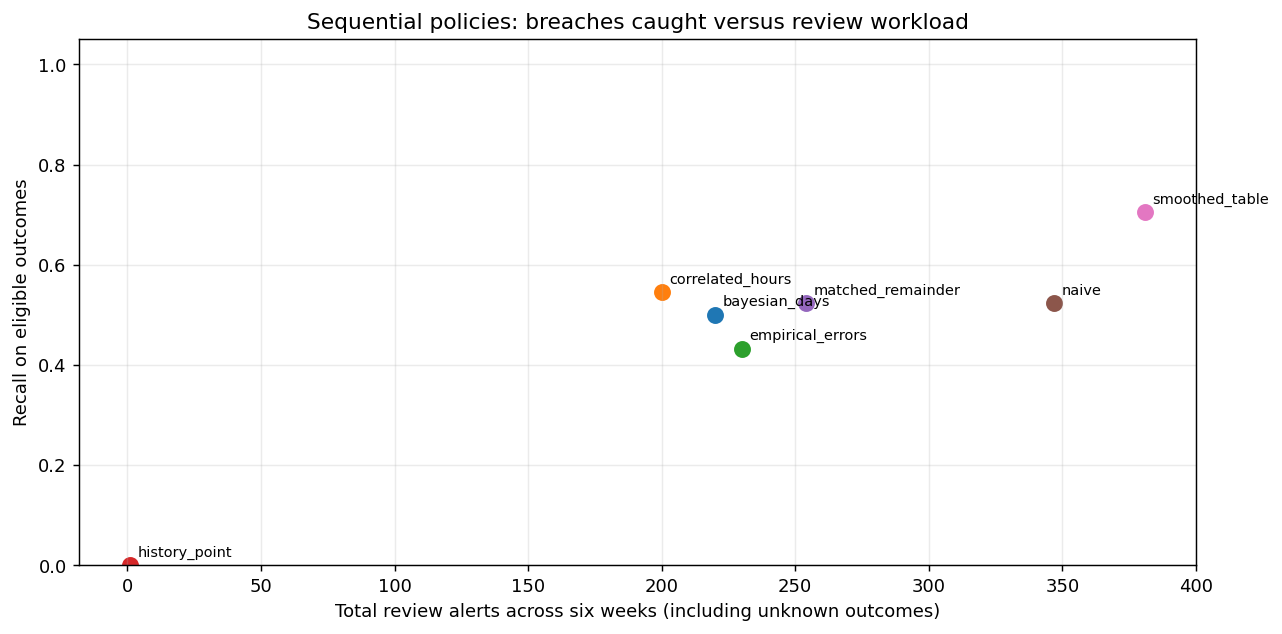

In [14]:
sf_legacy_data=sf_build_dataset(SF_SOURCE,SF_LABELS,convention='shift_date')
sf_legacy_predictions=pd.concat([sf_predict_week(sf_legacy_data,SF_SOURCE,w) for w in SF_WEEKS[1:]],ignore_index=True)
sf_legacy_decisions,sf_legacy_thresholds=sf_apply_policy(sf_legacy_predictions)
sf_legacy_results=sf_summarise(sf_legacy_decisions)
print('Sensitivity only: full Wednesday-starting shifts:')
display(sf_legacy_results.round(4))

sf_errors=sf_decisions.loc[sf_decisions.label_eligible&sf_decisions.policy.isin(['F2','fixed55'])
    &sf_decisions.alert.ne(sf_decisions.target_will_breach)].copy()
sf_errors['error_type']=np.where(sf_errors.alert.eq(1),'false_alert','missed_breach')
print('Missed breaches by method/week:')
display(sf_errors.loc[sf_errors.error_type.eq('missed_breach'),[
    'method','week_start','employee_id','A','carry','days','usual_hours','score','threshold','total_hours']].round(4))

primary=sf_main_results.loc[sf_main_results.policy.isin(['F2','fixed55'])].copy()
fig,ax=plt.subplots(figsize=(10,5))
for row in primary.itertuples():
    ax.scatter(row.all_alerts,row.recall,s=70)
    ax.annotate(row.method,(row.all_alerts,row.recall),xytext=(4,5),textcoords='offset points',fontsize=8)
ax.set(xlabel='Total review alerts across six weeks (including unknown outcomes)',
       ylabel='Recall on eligible outcomes',ylim=(0,1.05),title='Sequential policies: breaches caught versus review workload')
ax.grid(alpha=.25);fig.tight_layout();plt.show()


Verification and outputs

Checks cover strict threshold semantics, all-employee coverage, common labels,
exclusion of future references, unavailable clock-outs, and earlier-only alert
thresholds. The future-label perturbation check changes all prediction-week
labels/outcomes while holding earlier records fixed. Prediction and threshold
results must remain unchanged. These checks cannot verify absent entry timestamps.

CSV outputs contain HISTORICAL forecasts only. No predictions.csv or final
current-week submission is created. Lower errors in a reused benchmark do not
establish independent validation; new weeks are still required.


In [15]:
assert np.array([54.99,55.,55.01]).__gt__(55).tolist()==[False,False,True]
assert not sf_predictions.duplicated(['method',*KEY]).any()
assert sf_predictions.week_start.lt(CURRENT_WEEK).all()
assert sf_predictions.groupby(['week_start','method']).size().eq(len(employees)).all()
assert sf_predictions.loc[sf_predictions.method.isin(SF_METHODS),'score'].between(0,1).all()
assert sf_thresholds.threshold_last_week.lt(sf_thresholds.week_start).all()
for (week,method),g in sf_predictions.groupby(['week_start','method']):
    expected=SF_LABELS.loc[SF_LABELS.week_start.eq(week)].set_index(KEY).target_will_breach.sort_index()
    pd.testing.assert_series_equal(g.set_index(KEY).target_will_breach.sort_index(),expected)

probe=pd.Timestamp(SF_MAIN_WEEKS[0]);end=probe+pd.Timedelta(days=3)
old_snapshot,_=sf_snapshot(SF_SOURCE,probe)
masked_source=SF_SOURCE.copy()
mask=masked_source.week_start.eq(probe)&masked_source.end_at.gt(end)
masked_source.loc[mask,['end_at','recorded_hours']]=[pd.NaT,np.nan]
masked_snapshot,_=sf_snapshot(masked_source,probe)
pd.testing.assert_frame_equal(old_snapshot,masked_snapshot)
truncated,_=sf_snapshot(SF_SOURCE.loc[SF_SOURCE.shift_date.lt(end)],probe)
pd.testing.assert_frame_equal(old_snapshot,truncated)

changed=sf_data.copy()
changed.loc[changed.week_start.ge(probe),['target_will_breach','total_hours','R','forecast_error']]=0
changed.loc[changed.week_start.ge(probe),'label_eligible']=False
replay=sf_predict_week(changed,SF_SOURCE,probe)
original=sf_predictions.loc[sf_predictions.week_start.eq(probe)]
assert np.allclose(replay.score,original.score)
source_past=SF_SOURCE.loc[SF_SOURCE.week_start.lt(probe)]
# sf_predict_week reads current inputs from its supplied snapshot and only earlier source durations.
without_future=sf_predict_week(sf_data,source_past,probe)
assert np.allclose(without_future.score,original.score)
altered_predictions=sf_predictions.copy()
altered_predictions.loc[altered_predictions.week_start.ge(probe),'target_will_breach']=0
_,rules_after=sf_apply_policy(altered_predictions)
pd.testing.assert_frame_equal(sf_thresholds.loc[sf_thresholds.week_start.eq(probe)].reset_index(drop=True),
    rules_after.loc[rules_after.week_start.eq(probe)].reset_index(drop=True))
print('All meaningful verification checks passed.')

SF_OUTPUT=Path('jem_five_statistical_outputs');SF_OUTPUT.mkdir(exist_ok=True)
sf_exports=dict(historical_forecasts=sf_predictions,weekly_thresholds=sf_thresholds,
    main_results=sf_main_results,reused_final_two_weeks=sf_recent_results,weekly_results=sf_weekly,
    review_budget_comparison=sf_budget,probability_metrics=sf_probability,calibration=sf_calibration,
    historical_errors=sf_errors,shift_date_sensitivity=sf_legacy_results)
for name,frame in sf_exports.items():frame.to_csv(SF_OUTPUT/f'{name}.csv',index=False)
print('Historical analysis outputs:',SF_OUTPUT.resolve())
print('No current-week forecasts generated.')


All meaningful verification checks passed.
Historical analysis outputs: /workspace/scratch/e23e1dbb1f0b/jem_five_statistical_outputs
No current-week forecasts generated.
